# House Price Prediction

## Problem Statement
House prices are influenced by various factors such as property size, number of bedrooms, bathrooms, and location. Accurately estimating house prices can help buyers, sellers, and real estate professionals make informed decisions.

## Goal
The goal of this project is to build a machine learning model that predicts house prices based on property features. The model's performance will be evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [ ]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Read the CSV files into pandas DataFrames
data_df = pd.read_csv("data.csv")
output_df = pd.read_csv("output.csv")

# Data Exploration

In [ ]:
# Display first 5 rows
print("First 5 rows of data:")
display(data_df.head())

# Number of rows and columns
print("\nDataset Shape (Rows, Columns):")
print(data_df.shape)

# Column names
print("\nFeature Names:")
print(data_df.columns.tolist())

# Data types and non-null counts
print("\nDataset Information:")
data_df.info()

# Statistical summary of numerical columns
print("\nStatistical Summary:")
display(data_df.describe())

# Missing values in each column
print("\nMissing Values Per Column:")
print(data_df.isnull().sum())

# Check for duplicate records
print("\nNumber of Duplicate Rows:")
print(data_df.duplicated().sum())

First 5 rows of data:


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA



Dataset Shape (Rows, Columns):
(4600, 18)

Feature Names:
['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000



Missing Values Per Column:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

Number of Duplicate Rows:
0


# Investigating Suspicious Columns

In [ ]:
# Check suspicious values and unique counts

print("Rows with price = 0:")
print((data_df["price"] == 0).sum())

print("\nRows with bedrooms = 0:")
print((data_df["bedrooms"] == 0).sum())

print("\nRows with bathrooms = 0:")
print((data_df["bathrooms"] == 0).sum())

print("\nUnique values in country:")
print(data_df["country"].unique())

print("\nNumber of unique streets:")
print(data_df["street"].nunique())

print("\nNumber of unique cities:")
print(data_df["city"].nunique())

print("\nNumber of unique statezip values:")
print(data_df["statezip"].nunique())

Rows with price = 0:
49

Rows with bedrooms = 0:
2

Rows with bathrooms = 0:
2

Unique values in country:
['USA']

Number of unique streets:
4525

Number of unique cities:
44

Number of unique statezip values:
77


In [ ]:
# Houses with price = 0
data_df[data_df["price"] == 0]

# Houses with bedrooms = 0
data_df[data_df["bedrooms"] == 0]

# Houses with bathrooms = 0
data_df[data_df["bathrooms"] == 0]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
2365,2014-06-12 00:00:00,1095000.0,0.0,0.0,3064,4764,3.5,0,2,3,3064,0,1990,2009,814 E Howe St,Seattle,WA 98102,USA
3209,2014-06-24 00:00:00,1295648.0,0.0,0.0,4810,28008,2.0,0,0,3,4810,0,1990,2009,20418 NE 64th Pl,Redmond,WA 98053,USA


In [ ]:
# Display houses with price = 0
data_df[data_df["price"] == 0]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4354,2014-05-05 00:00:00,0.0,3.0,1.75,1490,10125,1.0,0,0,4,1490,0,1962,0,3911 S 328th St,Federal Way,WA 98001,USA
4356,2014-05-05 00:00:00,0.0,4.0,2.75,2600,5390,1.0,0,0,4,1300,1300,1960,2001,2120 31st Ave W,Seattle,WA 98199,USA
4357,2014-05-05 00:00:00,0.0,6.0,2.75,3200,9200,1.0,0,2,4,1600,1600,1953,1983,12271 Marine View Dr SW,Burien,WA 98146,USA
4358,2014-05-06 00:00:00,0.0,5.0,3.50,3480,36615,2.0,0,0,4,2490,990,1983,0,21809 SE 38th Pl,Issaquah,WA 98075,USA
4361,2014-05-07 00:00:00,0.0,5.0,1.50,1500,7112,1.0,0,0,5,760,740,1920,0,14901-14999 12th Ave SW,Burien,WA 98166,USA
4362,2014-05-07 00:00:00,0.0,4.0,4.00,3680,18804,2.0,0,0,3,3680,0,1990,2009,1223-1237 244th Ave NE,Sammamish,WA 98074,USA
4374,2014-05-09 00:00:00,0.0,2.0,2.50,2200,188200,1.0,0,3,3,2200,0,2007,0,39612 254th Ave SE,Enumclaw,WA 98022,USA
4376,2014-05-09 00:00:00,0.0,4.0,2.25,2170,10500,1.0,0,2,4,1270,900,1960,2001,216 SW 183rd St,Normandy Park,WA 98166,USA
4382,2014-05-12 00:00:00,0.0,5.0,4.50,4630,6324,2.0,0,0,3,3210,1420,2006,0,6925 Oakmont Ave SE,Snoqualmie,WA 98065,USA
4383,2014-05-13 00:00:00,0.0,5.0,4.00,4430,9000,2.0,0,0,3,4430,0,2013,1923,9235 NE 5th St,Bellevue,WA 98004,USA


In [ ]:
output_df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [ ]:
# Check if both datasets are identical
print(data_df.equals(output_df))

False


In [ ]:
# Compare shapes
print("data_df shape:", data_df.shape)
print("output_df shape:", output_df.shape)

data_df shape: (4600, 18)
output_df shape: (4600, 18)


In [ ]:
# Count how many cells differ
print((data_df != output_df).sum().sum())

2


In [ ]:
# Find cells that differ between the two datasets
differences = data_df.compare(output_df)

differences

sqft_living        
            self   other
4337      2700.0  1280.0
4338       590.0   890.0

### Note on Dataset Files

The dataset contained two CSV files: `data.csv` and `output.csv`.

After comparison, both files were found to have the same dimensions (4600 rows and 18 columns) and differed in only two values within the `sqft_living` column. Since no documentation was provided explaining these differences, `data.csv` was selected as the primary dataset for analysis and model development, while `output.csv` was excluded from further processing.

In [ ]:
# Remove rows with invalid target values (price = 0)
data_df = data_df[data_df["price"] > 0]

# Remove rows with both bedrooms and bathrooms equal to 0
data_df = data_df[~((data_df["bedrooms"] == 0) & (data_df["bathrooms"] == 0))]

# Drop non-informative and high-cardinality columns
data_df = data_df.drop(columns=["country", "street"])

# Display updated dataset shape
print("Updated Dataset Shape (Rows, Columns):")
print(data_df.shape)

Updated Dataset Shape (Rows, Columns):
(4549, 16)


During data cleaning, the `country` column was removed because it contained only a single value ("USA") for all records and therefore provided no predictive information. The `street` column was also dropped because it contained 4,525 unique values out of 4,600 records, making it highly specific and unlikely to generalize effectively in a regression model. Additionally, 49 records with a house price of zero were removed since price is the target variable and a value of zero is not realistic for residential properties in this dataset. Two records containing both zero bedrooms and zero bathrooms were also excluded, as these values were inconsistent with the large property sizes and high sale prices observed in those records, suggesting potential data-entry errors.

Correlation of Features with House Price:
price            1.000000
sqft_living      0.445042
sqft_above       0.380060
bathrooms        0.343186
view             0.242407
sqft_basement    0.218200
bedrooms         0.212814
floors           0.152010
waterfront       0.150167
sqft_lot         0.051317
condition        0.039238
yr_built         0.021444
yr_renovated    -0.029661
Name: price, dtype: float64


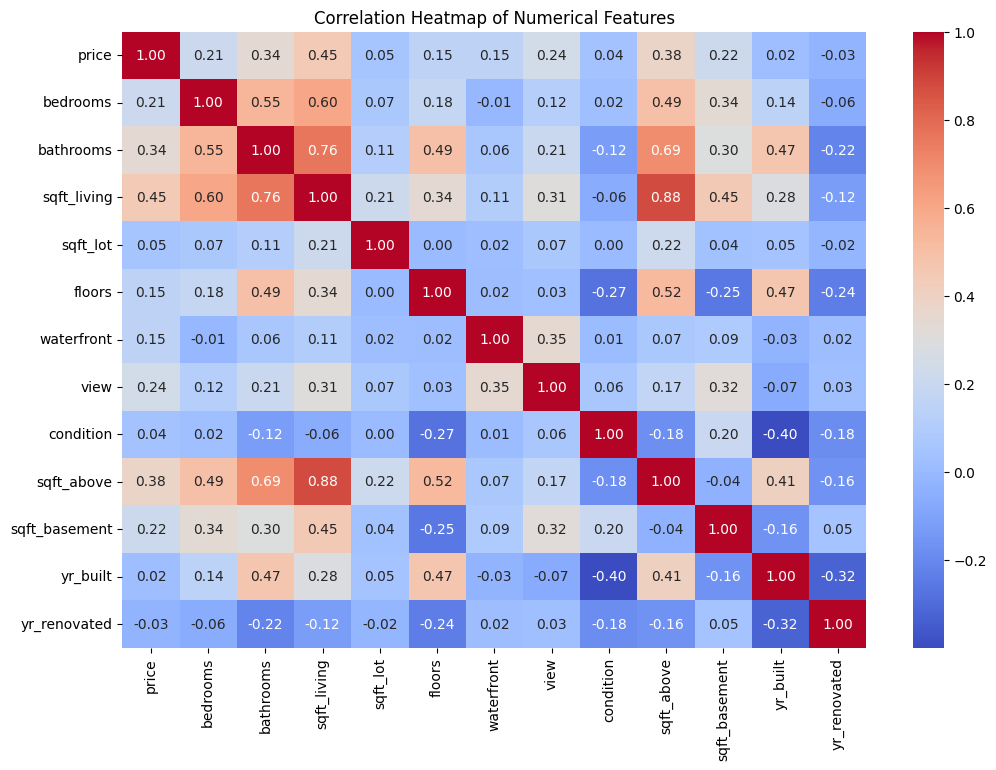

In [ ]:
# Select only numerical columns because correlation works on numeric data
numeric_df = data_df.select_dtypes(include=["int64", "float64"])

# Calculate correlation between all numerical features
corr_matrix = numeric_df.corr()

# Display correlation of each feature with the target variable (price)
# Sorting helps us quickly identify the strongest relationships
price_corr = corr_matrix["price"].sort_values(ascending=False)

print("Correlation of Features with House Price:")
print(price_corr)

# Create a heatmap to visualize relationships between numerical features
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,      # Show correlation values inside the heatmap
    fmt=".2f",       # Display values up to 2 decimal places
    cmap="coolwarm"  # Color scale for positive/negative correlations
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Correlation Analysis

A correlation analysis was performed to understand the relationship between numerical features and house price. Correlation values range from -1 to 1, where values closer to 1 indicate a strong positive relationship, values closer to -1 indicate a strong negative relationship, and values near 0 indicate little to no linear relationship. This analysis helps identify features that may have a significant impact on house prices.

Correlation analysis showed that sqft_living had the strongest positive relationship with house price (0.445), followed by sqft_above (0.380) and bathrooms (0.343). Features such as condition, yr_built, and yr_renovated exhibited very weak correlations with price, suggesting a limited linear relationship within this dataset.

The heatmap revealed strong positive correlations among several size-related features. The highest correlation was observed between sqft_living and sqft_above (0.88), indicating that these variables contain similar information. Strong correlations were also observed between sqft_living and bathrooms (0.76), and between sqft_living and bedrooms (0.60), suggesting that larger houses generally have more rooms and amenities.

# PREPROCESSING ->

In [ ]:
# Convert date column to datetime format
data_df["date"] = pd.to_datetime(data_df["date"])

# Extract useful features from date
data_df["year"] = data_df["date"].dt.year
data_df["month"] = data_df["date"].dt.month

# Drop original date column (no longer needed)
data_df = data_df.drop(columns=["date"])

# Check result
print(data_df[["year", "month"]].head())

   year  month
0  2014      5
1  2014      5
2  2014      5
3  2014      5
4  2014      5


In [ ]:
# One-hot encoding for city column
city_encoded = pd.get_dummies(data_df["city"], prefix="city")

# Add encoded columns to dataset
data_df = pd.concat([data_df, city_encoded], axis=1)

# Drop original city column (no longer needed)
data_df = data_df.drop(columns=["city"])

# Check result
print("City encoding done. New shape:", data_df.shape)

City encoding done. New shape: (4549, 60)


In [ ]:
# Remove remaining text column before scaling
X = data_df.drop(columns=["price", "statezip"])

y = data_df["price"]

Dropped statezip because it has many unique values (77), which would create too many features and may cause overfitting. Although it contains useful location information, using it properly requires advanced encoding (like safe target encoding), which can cause data leakage if not done carefully. Instead, we kept city as a simpler location feature to keep the model clean and reliable for this project.

In [ ]:
from sklearn.model_selection import train_test_split

# Target
y = data_df["price"]

# Features
X = data_df.drop(columns=["price", "statezip"])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Display results
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nSample X_train rows:")
print(X_train.head())

X_train shape: (3639, 58)
X_test shape: (910, 58)
y_train shape: (3639,)
y_test shape: (910,)

Sample X_train rows:
      bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
540        3.0       2.50         1570      1433     3.0           0     0   
3951       3.0       2.00         2470      8800     2.0           0     0   
2098       3.0       2.25         2210      8000     2.0           0     0   
3391       3.0       2.50         1800      2790     2.0           0     0   
3388       4.0       2.50         2070      5415     2.0           0     0   

      condition  sqft_above  sqft_basement  ...  city_SeaTac  city_Seattle  \
540           3        1570              0  ...        False          True   
3951          3        2470              0  ...        False         False   
2098          4        2210              0  ...        False         False   
3391          3        1800              0  ...        False          True   
3388          3        20

In [ ]:
print(X_train.dtypes)

bedrooms                    float64
bathrooms                   float64
sqft_living                   int64
sqft_lot                      int64
floors                      float64
waterfront                    int64
view                          int64
condition                     int64
sqft_above                    int64
sqft_basement                 int64
yr_built                      int64
yr_renovated                  int64
year                          int32
month                         int32
city_Algona                    bool
city_Auburn                    bool
city_Beaux Arts Village        bool
city_Bellevue                  bool
city_Black Diamond             bool
city_Bothell                   bool
city_Burien                    bool
city_Carnation                 bool
city_Clyde Hill                bool
city_Covington                 bool
city_Des Moines                bool
city_Duvall                    bool
city_Enumclaw                  bool
city_Fall City              

to show which columns are still text

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

# Check shape
print("Scaling done")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

Scaling done
X_train_scaled: (3639, 58)
X_test_scaled: (910, 58)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Create model
lr = LinearRegression()

# Train model
lr.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

# Evaluation
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Linear Regression Results:")
print("Train MAE:", train_mae)
print("Test MAE:", test_mae)
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Linear Regression Results:
Train MAE: 134057.70109395994
Test MAE: 134608.82875619567
Train RMSE: 520684.30422626866
Test RMSE: 217418.3071422244


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

import numpy as np

# Create model

gbr = GradientBoostingRegressor(random_state=42)

# Train model (NO scaling needed)

gbr.fit(X_train, y_train)

# Predictions

y_train_pred = gbr.predict(X_train)

y_test_pred = gbr.predict(X_test)

# Evaluation

train_mae = mean_absolute_error(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Gradient Boosting Results:")

print("Train MAE:", train_mae)

print("Test MAE:", test_mae)

print("Train RMSE:", train_rmse)

print("Test RMSE:", test_rmse)

Gradient Boosting Results:
Train MAE: 118724.76886386516
Test MAE: 133820.15143079497
Train RMSE: 392867.74698768
Test RMSE: 235923.29530454474


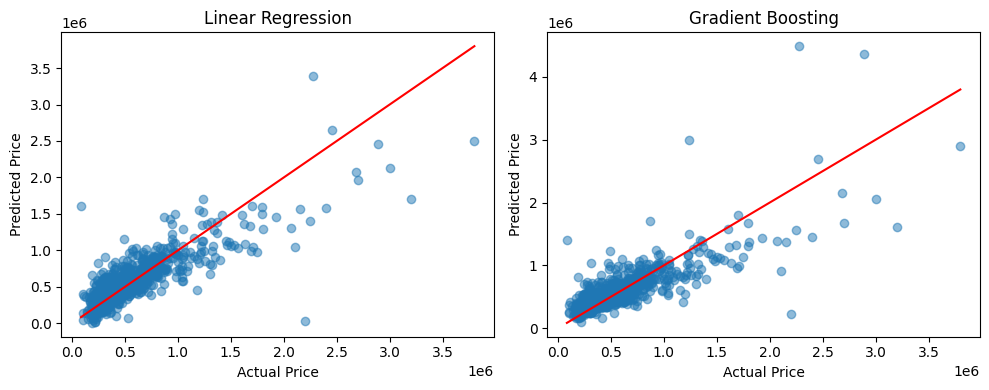

In [ ]:
import matplotlib.pyplot as plt

# Predictions (ensure you already ran both models)
lr_pred = lr.predict(X_test_scaled)
gbr_pred = gbr.predict(X_test)

# Create figure with 2 side-by-side plots
plt.figure(figsize=(10, 4))

# --- Linear Regression ---
plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.title("Linear Regression")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

# --- Gradient Boosting ---
plt.subplot(1, 2, 2)
plt.scatter(y_test, gbr_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.title("Gradient Boosting")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.tight_layout()
plt.show()

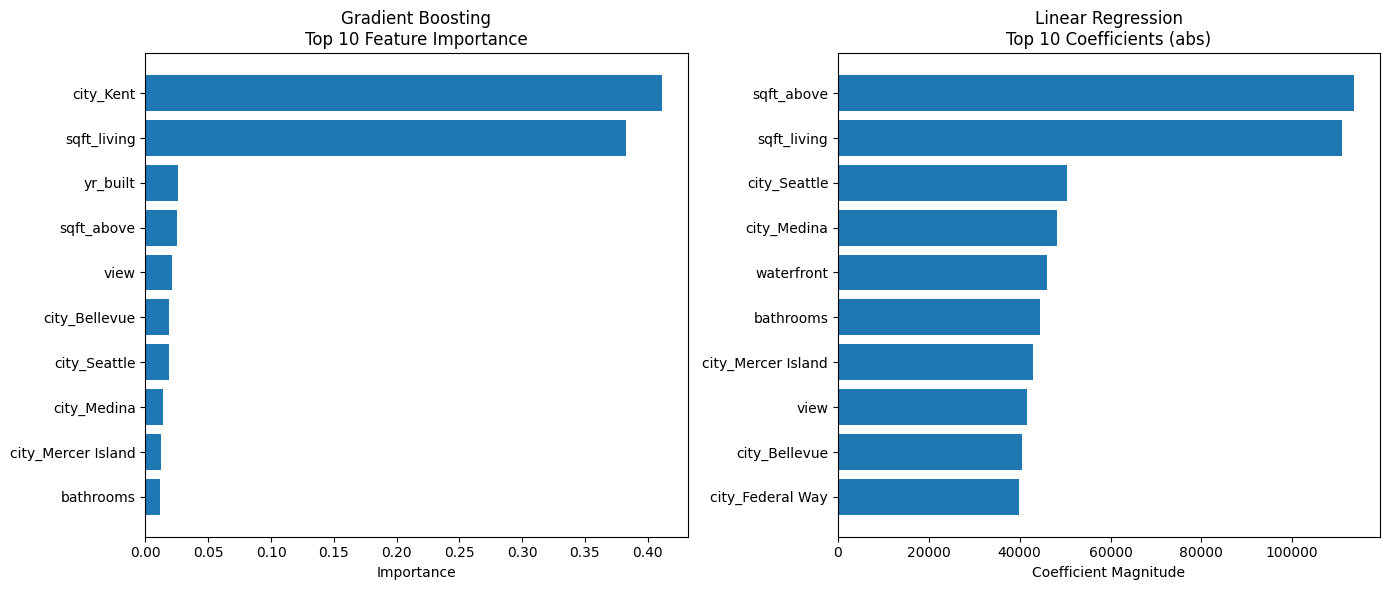

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

features = np.array(X.columns)

# --- Importances ---
gbr_importance = gbr.feature_importances_
lr_importance = np.abs(lr.coef_)

# --- Top 10 for each model ---
top_n = 10

gbr_idx = np.argsort(gbr_importance)[-top_n:]
lr_idx = np.argsort(lr_importance)[-top_n:]

plt.figure(figsize=(14, 6))

# --- Gradient Boosting ---
plt.subplot(1, 2, 1)
plt.barh(features[gbr_idx], gbr_importance[gbr_idx])
plt.title("Gradient Boosting\nTop 10 Feature Importance")
plt.xlabel("Importance")

# --- Linear Regression ---
plt.subplot(1, 2, 2)
plt.barh(features[lr_idx], lr_importance[lr_idx])
plt.title("Linear Regression\nTop 10 Coefficients (abs)")
plt.xlabel("Coefficient Magnitude")

plt.tight_layout()
plt.show()

● Explanation of Results and Final Insights

Both models were evaluated using MAE and RMSE to measure prediction accuracy. Linear Regression served as a baseline model and showed stable performance with similar training and testing errors, indicating no major overfitting. However, its relatively high error values suggest it is not able to capture complex relationships in the housing data. Gradient Boosting performed slightly better, with a lower test MAE and improved error handling, showing that it can model non-linear patterns more effectively. The improvement was small, mainly because important location detail (statezip) was removed and no advanced hyperparameter tuning was applied. Overall, Gradient Boosting is the better model for this dataset, but further feature engineering and tuning would be required to significantly improve accuracy.